# Daniel's Guide to Quantifying Uncertainty in Turbulence Statistics

There are three main types of uncertainty we need to consider in turbulence analysis:

| Type of uncertainty    | Source | Decreases with |
| -------- | ------- |  ------- |
| Measurement/data  | Errors during data acquisition, *e.g., instrument noise, calibration drift* | Instruments that are less noisy, better calibrated, more precise |
| Sampling/statistical | Estimating ensemble averages from a finite dataset *e.g. structure functions, power spectra* | Larger sample size, less variable population |
| Fitting/model | Fitting a model *e.g. straight-line in log-log space to obtain scaling exponent* | Better model fit |

We want a confidence interval for the slopes that accounts for the various types of error.

1. **Account for measurement error:** 

(This is error that )

- Subtract the bias introduced by the random/statistical component of the error.

- Systematic measurement error can be ignored as it cancels out when computing fluctuations/increments, assuming it does not change over time. If it does, e.g. in the case of *calibration drift*, you will need to de-trend the data in some way.

2. **Account for sampling and fitting error:** 

(This is error that....)

The last two are closely linked, and both represent in some sense how variable or noisy the data is, and therefore how much it is likely to vary between samples. Ultimately what we tend to want is an estimate of the slope, break, or kurtosis from a given interval, in such a way that preserves the properties of the original time series, especially its autocorrelation. Bootstrapping is a common way that is distribution-free, but we need to be careful to respect the autocorrelation structure.

- If you have evenly-sampled data and time on your hands, use the wavelet bootstrap approach described by Wendt et al. This is the most robust approach.

- If you have gaps and/or want a quick, reasonable estimate, use residual bootstrapping. You should check that the residuals are reasonably uncorrelated first.   

- If you have gaps and want the spread of SFs as well as the the spread of slopes, use block bootstrapping of the original time series, re-computing the SF and slope for each new time series to obtain your distribution of slopes. Block size should be comparable to a correlation time, and you may want to ignore points near block transitions as these can introduce artificial jumps, thereby increasing intermittency.

(Comments on jacknifing)


For spectra, people have bootstrapped the fits by residual resampling. You just fit your power-law, then add the residuals to the fit and re-fit. This perturbs the amplitudes around the best-fit model ([Carbone et al., 2020](https://www.mdpi.com/2218-1997/6/8/116), Telloni et al. 2021, Carbone et al. 2021):

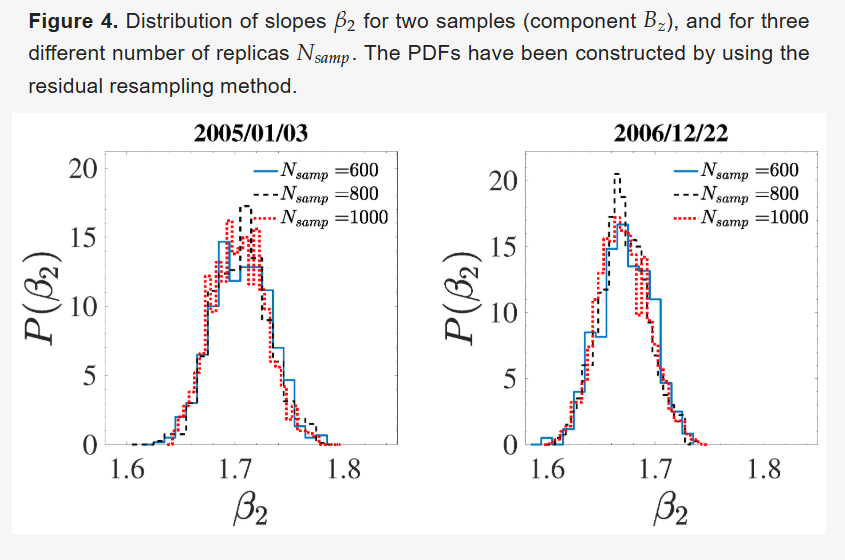

Related to the sampling uncertainty, there are concerns for the convergence of turbulence curves due to related issues around:

- stationarity: [Jagarlamudi et al. (2019)](https://iopscience.iop.org/article/10.3847/1538-4357/aaef2e/meta), [Kiyani et al. (2009)](https://scholar.google.com/scholar_url?url=https://journals.aps.org/pre/abstract/10.1103/PhysRevE.79.036109&hl=en&sa=T&oi=gsr-r&ct=res&cd=0&d=2750058327989828896&ei=5Ez_Z770FJGu6rQPyMPCuAs&scisig=AFWwaeb-9Mc5aBKqvPIk-kslCK3W)
- interval length: [Isaacs et al. (2015)](https://agupubs.onlinelibrary.wiley.com/doi/abs/10.1002/2014ja020661)

These are not covered here, but we invite the reader to review the cited literature.

**What about downsampling the time series? Bins? Freedman-Diaconis rule

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

## Demo datasets

1. **Simulated data:** Fractional Brownian motion with a Hurst parameter of $H=1/3$, which gives our K41 scaling.

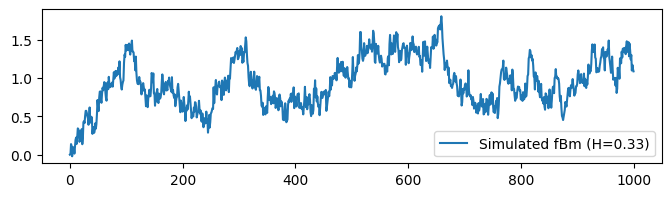

In [2]:
# Simulate fractional Brownian motion
np.random.seed(43)

n = 1000  # Number of points

hurst = 1 / 3  # Hurst parameter (0 < H < 1) = alpha/p for SF scaling
fbm_sim = FBM(n=n, hurst=hurst, length=1)
ts_sim = fbm_sim.fbm()

# Simulate AR(1) process
# phi = 0.9
# noise = np.random.normal(0, 1, n)
# ts_sim = np.zeros(n)
# for i in range(1, n):
#     ts_sim[i] = phi * ts_sim[i - 1] + noise[i]
plt.figure(figsize=(8, 2))
plt.plot(ts_sim, label=f"Simulated fBm (H={hurst:.2f})")
plt.legend()

2. **Real data:** Magnetic measurements of the LISM from Voyager 1. Uncertainties are as follows (from [Burlaga et al. 2018](https://iopscience.iop.org/article/10.3847/1538-4357/aaa45a/pdf)):

| Component | Full uncertainty (systematic + statistical) ( $\pm\sigma$ nT) | Statistical uncertainty ($\pm\sigma$ nT) |
| -------- | ------- |  ------- |
| $B_R$ | 0.06 | 0.005 |
| $B_T$ | 0.02 | 0.005 |
| $B_N$ | 0.02 | 0.005 |

In [3]:
data_full = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
data_res = data_full.resample("48s").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


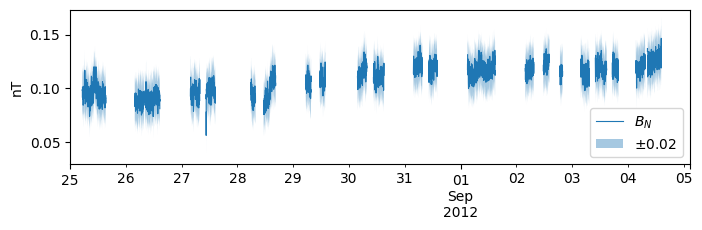

In [4]:
# Extract and plot the subset we'll study
v1_mag = data_res["BN"].iloc[:20000]
v1_err = 0.02

plt.figure(figsize=(8, 2))
v1_mag.plot(label="$B_N$", lw=0.8)

plt.fill_between(
    v1_mag.index,
    v1_mag - v1_err,
    v1_mag + v1_err,
    alpha=0.4,
    label=f"$\pm {v1_err}$",
)
plt.ylabel("nT")
plt.legend()

## Measurement uncertainty

Imprecision in the recording of data leads to measurement uncertainty. We can represent this error as a random variable $\mathbf{\epsilon}$ that is added to the 'true' value of our data $\mathbf{X}$, in order to get our observed values $\hat{\mathbf{X}}$:

$$\hat{\mathbf{X}}=\mathbf{X}+\mathbf{\epsilon}$$

This error $\epsilon$ can have two components: 

1. **systematic error**, which is generally a consistent offset to the true value (i.e., a *bias*). In this case of Voyager this results from issues around contamination by the spacecraft's magnetic field and telemetry errors, and comprises the majority of the error term. While it can generally be ignored since any bias is cancelled out when computing increments/fluctuations, it can still be important when there is this error is not constant (i.e., subject to *drift*).
1. **random/statistical error**. This is also referred to as *noise*, and in the case of magnetic field data usually results from instrument (thermal) noise and digitization errors. We always need to directly handle this error, and we will focus on this for the rest of this demonstration.

Statistical (measurement) error is typically assumed to be independent and identically distributed (i.i.d.) across all observations, and independent of the true signal. Additionally, it is modeled as normally distributed with zero mean and variance $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$:

$$\mathbf{\epsilon}\sim N(0,\mathbf{\sigma}_{\mathbf{\epsilon}}^2)$$

We can get $\mathbf{\sigma}^2_\mathbf{\epsilon}$ by noting that typically data error bars in literature are expressed as $\mathbf{X}\pm\mathbf{\sigma}_\mathbf{\epsilon}$. (In some cases they may represent 95\% confidence intervals, in which case what is really expressed is $\mathbf{X}\pm1.96\mathbf{\sigma}_\mathbf{\epsilon}$.)

**This error does not affect the mean of our data**:

$$E[\hat{\mathbf{X}}]=E[\mathbf{X}+\mathbf{\epsilon}]=E[\mathbf{X}]+E[\mathbf{\epsilon}]=E[\mathbf{X}]$$

This follows from $E[A+B]=E[A]+E[B]$

**But it does inflate the variance**:

$$\text{Var}[\hat{\mathbf{X}}]=\text{Var}[\mathbf{X}+\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]+\text{Cov}[X,\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

This follows from $\text{Var}(A+B)=\text{Var}(A)+\text{Var}(B)+\text{Cov}(A,B)$

**Seeing as the second-order structure function $\text{SF}$ is a measure of variance, it is also inflated by measurement error.** And since it is a function of two random variables $X_i, X_j$, with the same error distribution, we get two times the error variance as our upwards bias:

$$E[\hat{\text{SF}}(\tau)]=\text{SF}(\tau)+2\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

The full derivation of this is given in [Cucchetti et al. (2019)](https://www.aanda.org/articles/aa/pdf/2019/09/aa35677-19.pdf), Appendix A.3 and [ZuHone, Markevitch, and Zhuravleva (2019)](https://iopscience.iop.org/article/10.3847/0004-637X/817/2/110/pdf), Appendix C. (In those papers, they represent $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$ as $\mathbf{\sigma}^2_{stat}$, to distinguish it from the systematic error variance $\mathbf{\sigma}^2_{sys}$.) They then show the downwards correction of this bias in their Figures 3 and 5, respectively:

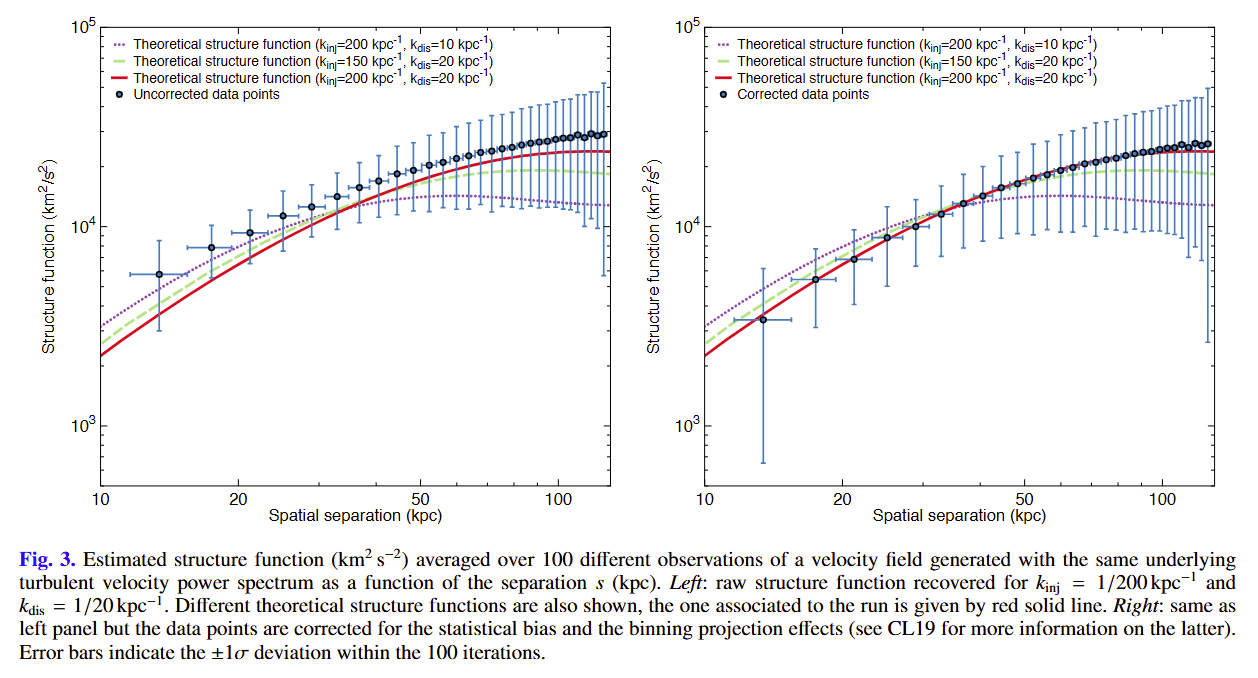

*^ From [Cucchetti et al. (2019)](https://www.aanda.org/articles/aa/pdf/2019/09/aa35677-19.pdf). In the right panel we can see that after subtracting the bias, the points lie much more in line with the red theoretical model.*

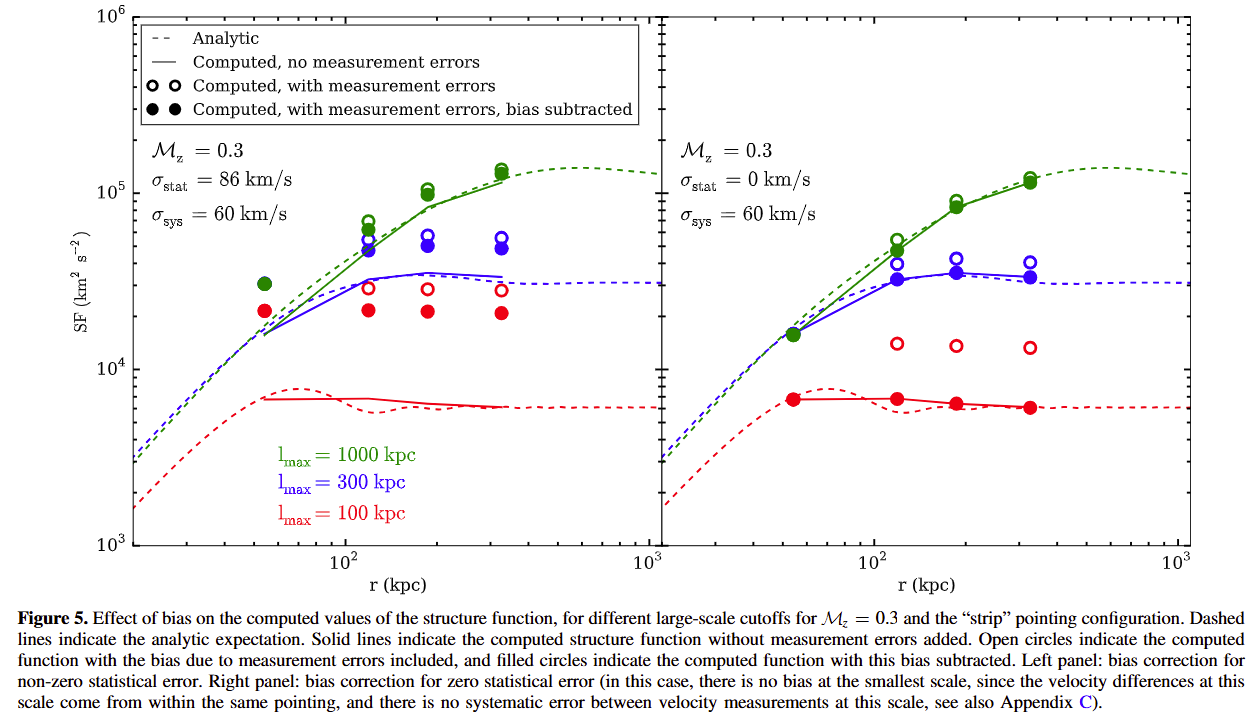

*^ From [ZuHone, Markevitch, and Zhuravleva (2019)](https://iopscience.iop.org/article/10.3847/0004-637X/817/2/110/pdf). Again, measurement errors cause upwards bias. Bias is strongest for the structure function with a small injection scale (red line). Their systematic error describes an error which is a constant offset within a given chunk of data (and therefore cancels out), but varies across chunks ('pointings'), and therefore needs modelling with a variance $\sigma_{sys}$. Given it does often cancel out, overall we see that statistical error is the dominant contributor to the bias.*

The former paper also derives the error that propagates into the four-term *variance* of the structure function, which we need for calculating confidence intervals:

$$\text{Var}[\hat{\text{SF}}(\tau)]=\text{Var}[\text{SF}(\tau)]+4\text{Var}[\text{D}(\tau)]\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4}{N(\tau)}\text{SF}(\tau)\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4(N_{nei}(\tau)+1)}{N(\tau)}\mathbf{\sigma}_{\mathbf{\epsilon}}^4$$

where $D(\tau)$ is the increment function (first-order SF), $N(\tau)$ is the number of lag pairs at lag $\tau$, and $N_{nei}(\tau)$ is the number of neighbours at a distance of $\tau$ at any given point.

If we have zero uncertainty in the data, this variance reduces to a single term: the 'intrinsic variance' of the structure function $\text{Var}[\text{SF}(\tau)]$. This is the uncertainty that results from sampling: **see next section**.

### Demo on simulated data
We can demonstrate the effect of measurement error by simulating it (given the error distribution), adding it to the time series, calculating the structure function, and doing this many times.

In [5]:
# Define function to "bootstrap" structure functions from time series with noise


def simulate_noise(x, max_lag, sigma_eps=None, snr=None, n_samples=1000, data_name="", plot_minus=False,  plot_noise_sf=False, log_axes=True):

    n = len(x)
    if sigma_eps is None:
        # Choose sigma such that the signal-to-noise ratio is snr
        sigma_eps = np.sqrt(np.var(x) / snr)
    if snr is None:
        # Calculate the signal-to-noise ratio
        snr = np.var(x) / sigma_eps**2

    # Remove any dated index (doesn't show up good in x-axis ticklabels)
    if type(x) == pd.Series:
        if type(x.index) == pd.DatetimeIndex:
            x.reset_index(drop=True, inplace=True)

    sf_true = sf_funcs.compute_sf(
        pd.DataFrame(x), np.arange(1, max_lag + 1), [2], False, False, None
    ).sf_2
    sf_noise = sf_funcs.compute_sf(
        pd.DataFrame(np.random.normal(0, sigma_eps, len(x))),
        np.arange(1, max_lag + 1),
        [2],
        False,
        False,
        None,
    ).sf_2

    sf_boot = np.zeros((n_samples, max_lag))

    x_boot_all = []

    for b in range(n_samples):

        x_boot = x + np.random.normal(0, sigma_eps, len(x))
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(

            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None


        ).sf_2

    # PLOT RESULTS
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    for x_boot in x_boot_all:
        ax[0].plot(x_boot, c="grey", alpha=0.1)
    ax[0].plot(
        x_boot[0],
        label=f"X +$\epsilon, \epsilon \sim N(0,\sigma^2_{{\epsilon}})$ ({n_samples} samples)",
        color="grey",
    )
    ax[0].plot(x, label=f"X ({data_name})", color="blue")
    # Reorder the legend
    handles, labels = ax[0].get_legend_handles_labels()
    handles = [handles[1], handles[0]]
    labels = [labels[1], labels[0]]
    ax[0].legend(handles, labels, loc="upper left")

    ci_lower = np.percentile(sf_boot, 2.5, axis=0)
    ci_upper = np.percentile(sf_boot, 97.5, axis=0)

    # Plot
    lags = np.arange(1, max_lag + 1)

    ax[1].plot(lags, sf_true, label="SF(X)", color="blue")

    if plot_noise_sf:
        sf_noise = sf_funcs.compute_sf(
            pd.DataFrame(np.random.normal(0, sigma_eps, len(ts))),
            np.arange(1, max_lag + 1),
            [2],
            False,
            False,
            None,
        )

        ax[1].plot(
            lags, sf_noise.sf_2, label="SF($\epsilon_i$)", color="pink", alpha=0.8, lw=0.8
        )

    if plot_minus:
        sf_corr = sf_true - 2 * sigma_eps**2
        sf_corr_pos = sf_corr[sf_corr > 0]
        lags_corr_pos = lags[sf_corr > 0]
        ax[1].plot(
            lags_corr_pos,
            sf_corr_pos,
            label="SF(X) - 2$\sigma_{\epsilon}^2$",
            color="black",
            linestyle="--",
        )

        # Set ylimits
        # ax[1].set_ylim(sf_corr.min(), sf_true.max())
    else:
        for sf in sf_boot:
            ax[1].plot(lags, sf, color="grey", alpha=0.2)
        ax[1].plot(lags, sf_boot[0], color="grey", alpha=0.8, label="SF(X + $\epsilon_i$)")
        ax[1].plot(
            lags,
            sf_true + 2 * sigma_eps**2,
            label="SF(X) + 2$\sigma_{\epsilon}^2$",
            color="purple",
            linestyle="--",
        )
    # ax[1].plot(
    #     sf_true.lag[2:10],
    #     0.008 * np.power(sf_true.lag[2:10], 2 / 3),
    #     label="$\\tau^{2/3}$",
    #     color="black",
    #     linestyle=":",
    #     alpha=0.3,
    # )

    # ax[0].set_ylim(ts.min()-0.01, ts.max()+0.01)
    ax[0].set_title(
        f"Time series with added noise: ${{\sigma}}_{{\epsilon}}=${sigma_eps:.3f}, SNR={snr:.2f}"
    )
    ax[1].set_title(f"Corresponding structure functions")

    ax[1].set_xlabel("Lag (τ)")
    if log_axes:
        ax[1].set_xscale("log")
        ax[1].set_yscale("log")
    else:
        ax[1].axhline(2 * sigma_eps**2, color="gray", linestyle=":", label="2$\sigma_{\epsilon}^2$")
    # ax[1].set_ylim(0.01, 10)
    ax[1].legend(loc="lower right")
    # ax[1].set_ylim(5e-7,2e-4)
    fig.tight_layout()
    plt.show()

    return sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps

#### Comparing different amounts of measurement uncertainty

We can do this more intuitively by specifying the Signal-to-Noise Ratio (SNR), and then rearrange this to derive $\sigma_{\epsilon}$:

$$SNR=\frac{\text{Var}(\text{signal})}{\text{Var}\text{(noise)}}=\frac{\text{Var}(X)}{\sigma_{\epsilon}^2}$$

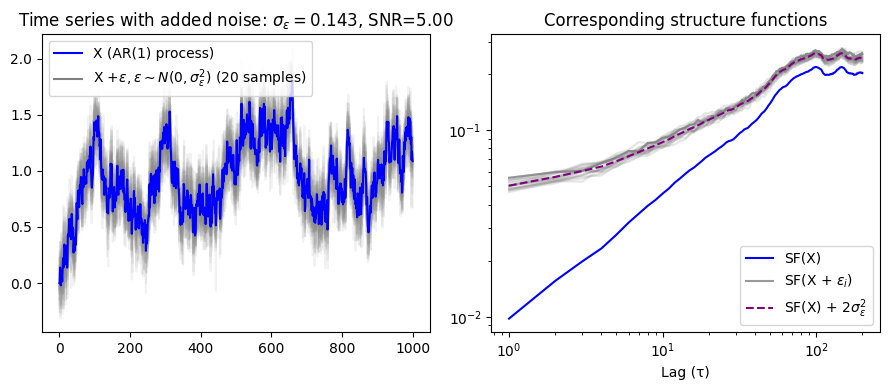

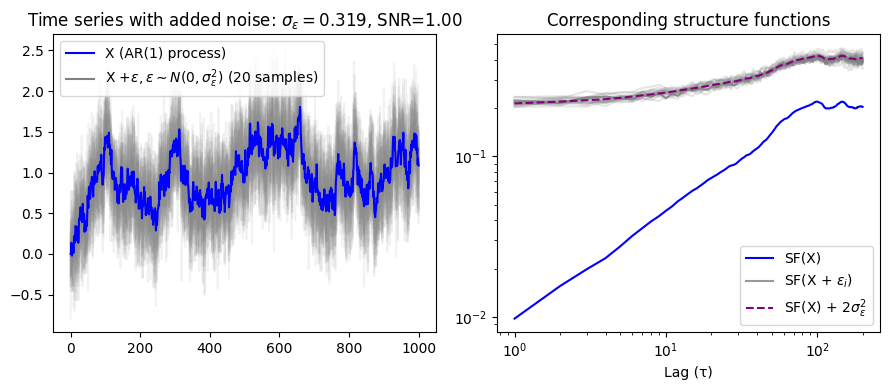

In [7]:
for snr in [5, 1]:
    sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
        x=ts_sim, max_lag=200, snr=snr, n_samples=20, data_name="AR(1) process"
    )

- The theoretical bias, given by the purple line in the right panel, matches very well with the results of our simulated noisy signals.
- Proportionally, measurement noise impacts small scales to a greater degree (small $\tau$) because that's where the signal differences are small. This scale-dependent effect results in a flattening of the curve in log-log space. **This will therefore lead to fitted slopes that are too small.**

### Demo on Voyager data

What we have with this real data is $\hat{\textbf{X}}$, not $\textbf{X}$, which means we should be *subtracting* $2\sigma_{\epsilon}^2$ from $\text{SF}$. We do this by changing an argument in the plotting function.

In [8]:
v1_err_stat = 0.005 # nT

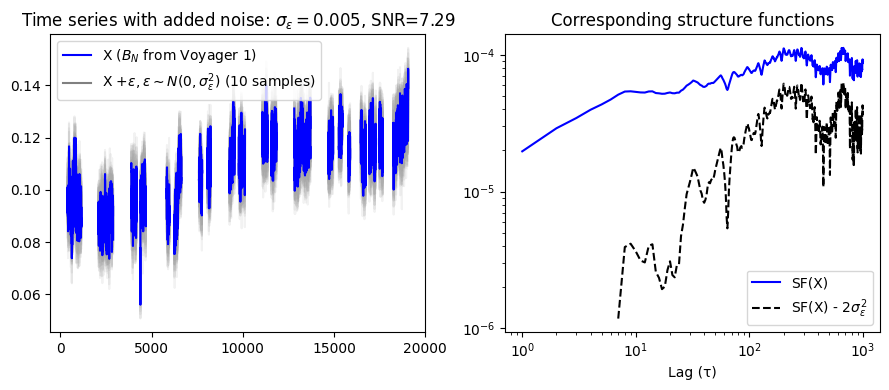

In [ ]:
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=v1_mag,
    max_lag=1000,
    sigma_eps=v1_err_stat,
    n_samples=5,
    data_name="$B_N$ from Voyager 1",
    plot_minus=True,
    log_axes=True
)

As expected, the corrected structure function is steeper. Note also we have had to disregard the first 6 lags where the corrected SF was smaller than zero.

What's particularly appealing about this correction is its relationship to the *nugget* effect which is described in relation to the jump from 0 to 1 that is observed in experimental variograms, and *has been identified with measurement noise*. We can observe this by switching to linear axes.

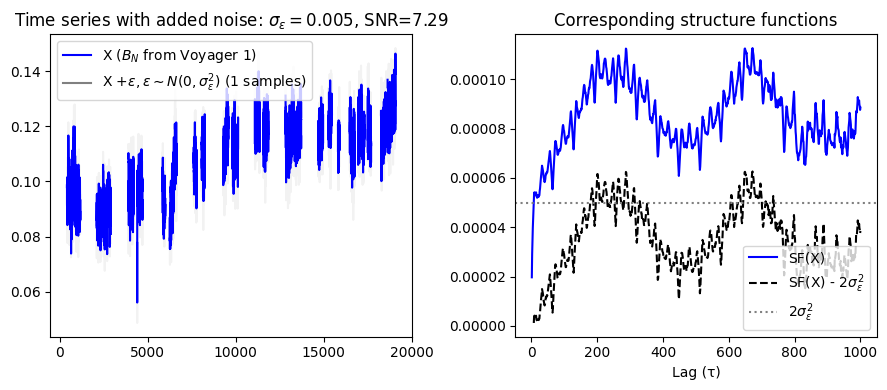

In [119]:
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=v1_mag,
    max_lag=1000,
    sigma_eps=v1_err_stat,
    n_samples=1,
    data_name="$B_N$ from Voyager 1",
    plot_minus=True,
    log_axes=False,
)

As shown by the dotted horizontal line, this jump lines up extremely well with the reported measurement error.

*But what if we're averaging the data, or binning the SFs?*

## Sampling uncertainty

We want to model the uncertainty under repeated measurement scenarios, and therefore assess the robustness of estimated scaling behaviour: if we were to observe a slightly different interval, how much could the SF differ? We know that it could differ by a larger amount at large $\tau$ (fewer sample pairs contribute), and higher-order structure functions (sensitive to rare, extreme events.) We invite the reader to consult the following works, which look at these two issues specifically in a solar wind turbulence context:

- [Dudok de Wit et al. (2004)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.70.055302) TLDR: sample size requirements mean you should never really go beyond 4th-order SF
- [Kiyani et al. (2006)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.74.051122) TLDR: strong influence of outliers on scaling exponents can be reduced by removing the most extreme ones. Has been employed in SW studies, e.g. Roberts et al. (2020)

In general, in order to quantify sampling uncertainty, we would like to know the distribution of estimates of the structure function.

The second-order structure function $\text{SF}(\tau)$, like any variance, is a positively skewed quantity, especially at small sample sizes. ([Emmanoulopoulos et al. (2010)](https://academic.oup.com/mnras/article-abstract/404/2/931/968488) suggest in their Fig. 8 that its distribution may be approximately log-normal at certain lags.)

In the ideal case of Gaussian data, [the sample variance follows a scaled chi-squared distribution](https://en.wikipedia.org/wiki/Variance#Population_variance_and_sample_variance). The standard error of the sample variance $S^2$ is then given by:

$$
\hat{\sigma}_{S^2} = S^2 \sqrt{\frac{2}{n - 1}}
$$

Applied to the structure function, this gives an approximate standard error:

$$
\sigma_{\text{SF}}(\tau) = \text{SF}(\tau) \sqrt{\frac{2}{N(\tau) - 1}}
$$

where $N(\tau)$ is the number of increment pairs at lag $\tau$. (As for what we specifically get when this variance is of the difference of two squared RVs: this has been derived by [Clec et al. (2019, Appendix F)](https://www.aanda.org/articles/aa/abs/2019/09/aa35676-19/aa35676-19.html) and [Ortiz & Deutsch (2002)](https://link.springer.com/article/10.1023/A:1014412218427).)

These analytical formulas can provide insight into how uncertainty scales with sample size
and lag. But there are issues at stake with these expressions. First is the assumption of
the shape of the distribution, which may only apply at large N.  For small $N(\tau)$ or heavy-tailed data, the SF distribution can deviate strongly from normality. 

Bootstrapping is a way to do this that involves re-sampling the original data, with replacement, in order to generate "plausible alternative realisations" of the data, while making no assumptions about the shape of the distribution.

In our case, we could generate "new" samples of squared increments at each lag, calculate the mean of each new sample, calculate the 2.5% and 97.5% percentiles, and use *this* as our estimate of the SF error **at each lag**. 


In [10]:
def get_lag_vals_list(df):
    lag_vals_wide = pd.DataFrame(df["diffs_2"].tolist(), index=df.index)
    lag_vals_wide.reset_index(inplace=True)  # Make the index a column
    lag_vals_wide.rename(columns={"index": "lag"}, inplace=True)
    lag_vals = pd.melt(
        lag_vals_wide, id_vars=["lag"], var_name="index", value_name="diffs_2"
    )
    return lag_vals

In [34]:
# Plot
ts = ts_sim
max_lag = 200

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)

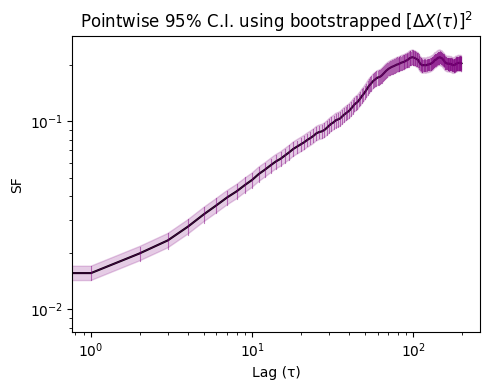

In [35]:
lags = np.arange(1, max_lag + 1)


# Calculate standard error assuming chi-squared approximation (pointwise error bars)

n_pairs = np.array([len(ts) - tau for tau in range(1, max_lag + 1)])
sf_se = sf_true.sf_2 * np.sqrt(2 / (n_pairs - 1))
ci_se_lower = sf_true.sf_2 - 1.96 * sf_se
ci_se_upper = sf_true.sf_2 + 1.96 * sf_se


# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(lags - 1, sf_true.sf_2, color="black")
lag_vals = get_lag_vals_list(sf_true)


# TAKES AGES FOR VOYAGER
sns.pointplot(
    x="lag",
    y="diffs_2",
    data=lag_vals,
    alpha=0.5,
    errorbar="ci",
    # n_boot=5,
    marker=None,
    c="purple",
    ax=ax,
    estimator="mean",
    lw=0.8,
)


ax.fill_between(
    lags - 1,
    ci_se_lower,
    ci_se_upper,
    color="purple",
    alpha=0.2,
)


ax.set_xlabel("Lag (τ)")
ax.set_ylabel("SF")
ax.set_title("Pointwise 95% C.I. using bootstrapped $[\Delta X(\\tau)]^2$")

ax.set_xscale("log")
ax.set_yscale("log")

fig.tight_layout()

plt.show()

The confidence interval based on the theoretical standard error of the sample variance, is approximately equal to the bootstrap confidence interval at a given lag (i.e., resampling with replacement the squared increments at that lag.) *This suggests that the raw differences are Gaussian enough, or the sample sizes large enough, for this convergence to occur.*

However, this **lag-wise bootstrapping** misses a vital fact about the data: data points, and therefore differences, are not independent. Pointwise confidence that we are currently expressing, either via analytical formulas or numerical simulation is inappropriate, and under-estimating the true uncertainty. In order to handle the serial correlation between lags, we need a method of calculating *joint* confidence intervals.

One way that has been suggested for dealing with autocorrelation is *block bootstrapping*. Doing this in blocks preserves at least *some* of the correlation structure. However, it does not preserve long-run correlations, *and* it can lead to discontinuities at the boundaries between blocks.

Block bootstrapping perserves short-to-intermediate scale autocorrelations, depending on the blocksize.
We need to make sure 
- the block size is large enough to retain sufficient autocorrelation, i.e., **block size > max lag > $\lambda_C$**
- given this block size, the signal is long enough for many blocks.

### Simulated data

In [17]:
def block_bootstrap_sf(x, max_lag, block_size, n_bootstraps=1000, random_state=None, plot=True, n_samples=3, data_name=""):

    def block_matches_with_na(block1, block2):
        """
        Check if two blocks match, accounting for NA values.
        Two blocks match if:
        1. Non-NA values in the same positions are close to each other
        2. NA patterns match (NA in block1 corresponds to NA in block2)
        """
        import numpy as np
        import pandas as pd

        # Convert to numpy arrays if they aren't already
        block1 = np.array(block1)
        block2 = np.array(block2)

        # Check if lengths match
        if len(block1) != len(block2):
            return False

        # Create masks for NA values
        mask1 = pd.isna(block1)
        mask2 = pd.isna(block2)

        # Check if NA patterns match
        if not np.array_equal(mask1, mask2):
            return False

        # For non-NA values, check if they are close
        non_na_indices = ~mask1  # Same as ~mask2 since we've verified they're equal

        # If all values are NA, blocks match
        if not np.any(non_na_indices):
            return True

        # Check if non-NA values are close
        return np.allclose(block1[non_na_indices], block2[non_na_indices], atol=1e-6)

    if random_state is not None:
        np.random.seed(random_state)


    n = len(x)
    n_blocks = n // block_size
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):

        indices = np.random.randint(0, n_blocks, n_blocks)
        x_boot = np.concatenate(


            [x[i * block_size : (i + 1) * block_size] for i in indices]
        )


        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    # return sf_boot, x_boot_all

    if plot:
        n = len(x)
        n_blocks = n // block_size

        fig, axes = plt.subplots(
            n_samples + 1, 1, figsize=(10, 1.5 * (n_samples + 1)), sharex=True
        )

        # --- x Time Series ---
        ax0 = axes[0]
        # Plot non-NA values and indicate NA values
        valid_mask = ~pd.isna(x)
        ax0.plot(np.arange(n), np.array(x), color="black")

        for i in range(n_blocks):
            start = i * block_size
            ax0.axvline(start, linestyle="--", alpha=0.5, color="black")

            ypos = np.nanmax(x) * 0.5
            if np.isnan(ypos):  # Handle case where all data might be NaN
                ypos = 0.5

            ax0.text(
                start + block_size / 2,
                ypos,
                f"{i}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
            )
        ax0.set_title(
            f"Original time series ({data_name}) with block indices", fontweight="bold"
        )
        ax0.axvline(n, linestyle="--", alpha=0.5, color="black")

        # --- Bootstrapped Samples ---
        for sample_idx in range(n_samples):
            sample = x_boot_all[sample_idx]
            ax = axes[sample_idx + 1]

            # Plot non-NA values in the bootstrap sample
            valid_mask_sample = ~pd.isna(sample)
            if np.any(valid_mask_sample):
                ax.plot(
                    np.arange(len(sample)),
                    np.array(sample),
                    color="black",
                    lw=0.5,
                )

            # Mark NA positions in bootstrap sample
            for i in range(0, len(sample), block_size):
                block = sample[i : i + block_size]

                # Identify origin block
                found_origin = -1
                for j in range(n_blocks):
                    orig_block = x[j * block_size : (j + 1) * block_size]
                    orig_block_size = min(block_size, len(orig_block))

                    # Compare blocks accounting for NAs
                    if block_matches_with_na(
                        block[:orig_block_size], orig_block[:orig_block_size]
                    ):
                        found_origin = j
                        break

                ax.axvline(i, linestyle="--", alpha=0.7, color="black")

                ypos = np.nanmax(sample) * 0.5
                if np.isnan(ypos):  # Handle case where all data might be NaN
                    ypos = 0.5

                ax.text(
                    i + block_size / 2,
                    ypos,
                    f"{found_origin}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    bbox=dict(
                        facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"
                    ),
                )

            # Add final vertical line for the last block
            ax.axvline(len(sample), linestyle="--", alpha=0.7, color="black")
            ax.set_title(f"Bootstrapped Sample ({sample_idx + 1})")

        plt.tight_layout()
        plt.show()

    return sf_boot, x_boot_all

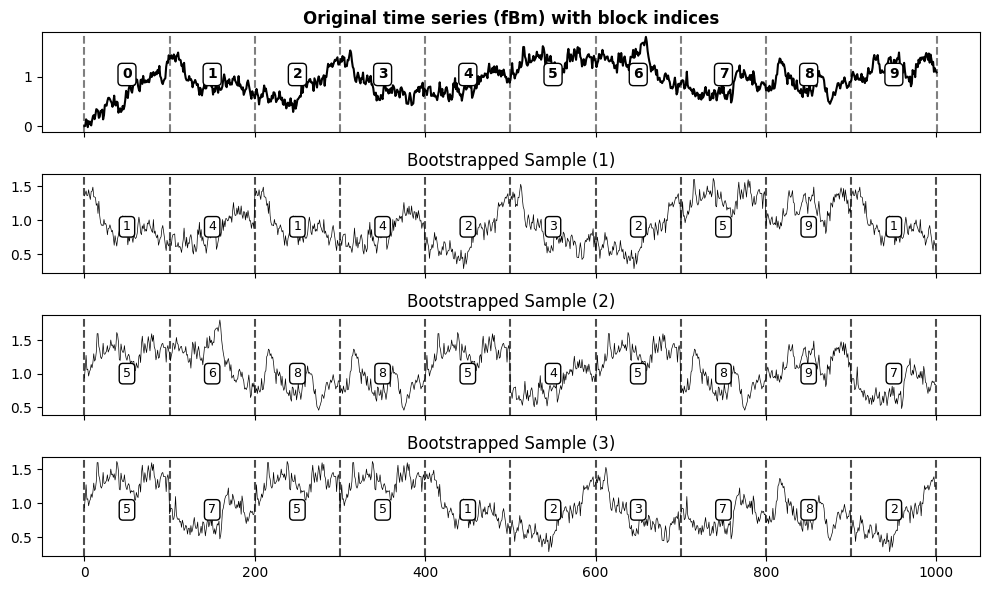

In [18]:
# Parameters
block_size = 100
n_bootstraps = 50
max_lag = 200

# Compute original SF and bootstrapped confidence intervals
ts = ts_sim

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)
sf_boot, x_boot = block_bootstrap_sf(ts, max_lag, block_size, n_bootstraps, data_name="fBm")

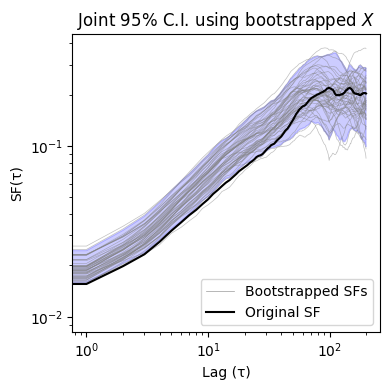

In [19]:
ci_lower = np.percentile(sf_boot, 2.5, axis=0)
ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax
fig, ax = plt.subplots(figsize=(4, 4))
for sf in sf_boot:
    ax.plot(lags-1, sf, color="grey", alpha=0.5, lw=0.5)
ax.plot(lags[0]-1, sf_boot[0][0], color="grey", alpha=0.8, lw = 0.5, label="Bootstrapped SFs")
ax.plot(lags-1, sf_true.sf_2, label="Original SF", color="black")


ax.set_xlabel("Lag (τ)")
ax.set_ylabel("SF(τ)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Joint 95% C.I. using bootstrapped $X$")
ax.legend(loc="lower right")

ax.fill_between(lags - 1, ci_lower, ci_upper, color="blue", alpha=0.2)

fig.tight_layout()
plt.show()

Uh-oh. Block-bootstrapped fBm time series have seriously inflated SF values, especially at small lags, such that the CI doesn't even contain the true SF. This is likely from the introduction of artificial sharp discontinuities (**intermittency**) at block boundaries. At large lags, the SFs cluster around the true SF, as these are less affected, and the total signal variance at which the SF plateaus, is not biased by the bootstrapping procedure.

Overlapping blocks is less 'chunky' and preserves local dependencies somewhat better. But in general, block bootstrapping is going to be problematic due to how it affects the true intermittency of the signal.

Is there a different way? Yes. 

A very relevant method has been developed which resamples not the increments, nor blocks of the time series, but the *wavelet leaders* of the time series. From these, the SFs and their corresponding slopes are estimated. It is described in depth, with turbulence analysis in mind, by [Wendt et al. (2007)](https://ieeexplore.ieee.org/document/4286563):

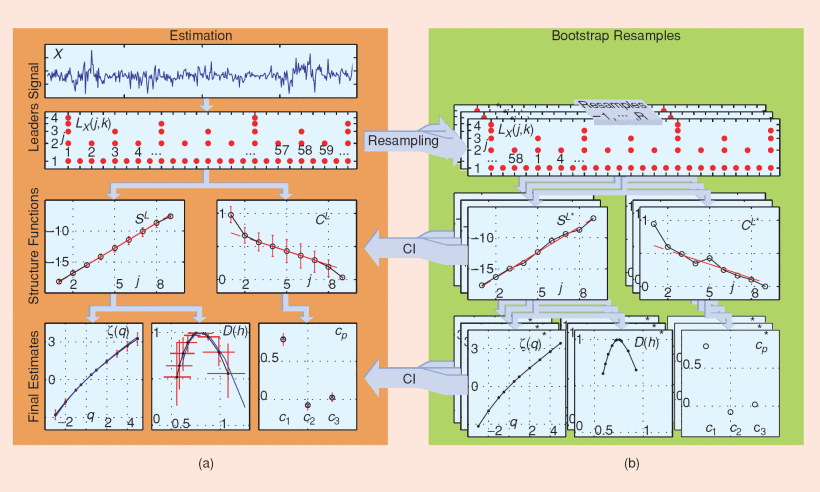

In [20]:
# MANUAL POINTWISE BOOTSTRAP OF SQUARED DIFFERENCES
# (this is already achieved by seaborn's sns.pointplot() above)

# # Initialize a dictionary to store the mean squared differences for each lag

# bootstrap_means = {}

# # Perform bootstrapping for 10 resamples
# n_resamples = 100
# for lag in lag_vals["lag"].unique():
#     bootstrap_means[lag] = []
#     for _ in range(n_resamples):
#         sq_diffs = lag_vals[lag_vals['lag'] == lag]["diffs_2"]
#         sq_diffs_resampled = sq_diffs.sample(frac=1.0, replace=True, random_state=None)
#         mean_sq_diff = np.mean(sq_diffs_resampled)
#         bootstrap_means[lag].append(mean_sq_diff)

# # Convert the results to a DataFrame for easier analysis
# bootstrap_means_df = pd.DataFrame(bootstrap_means)

# # Switch rows and columns
# bootstrap_means_df = bootstrap_means_df.transpose()

## Fit uncertainty

If we were just fitting a single scaling exponent, say from one structure function curve, then we would need to report the uncertainty in this. Also, we could propagate uncertainty at each lag using weighted regression.

However, if we were applying the above bootstrap procedure, we can ignore these uncertainties. The bootstrap distribution of scaling exponents naturally incorporates both sampling variability and the uncertainty associated with fitting individual exponents. As each bootstrap resample undergoes an independent fitting procedure, the resulting confidence intervals reflect the combined effects of data variability and finite-size fitting noise, without requiring separate estimation of fitting uncertainty.

This method is indeed commonly used in the literature for slopes, and kurtosis in particular

- Roberts et al. (2020, Frontiers in Physics) and (2022, JGRSP) performed 100 bootstrap resamplings of the fluctuations to derive errors bars for the kurtosis and structure functions.
- Duan et al. (2018) use bootstrapping to get error bars of the spectral break, by removing two random frequencies and re-fitting their power-laws.
- Carbone et al. (2020) used 600-1000 bootstrap resamples of the power spectrum and Hilbert spectrum to get error bars for the fitted slopes. I'm guessing by removing values from the spectra?



- \citet{bowen2024mediation} boostrapped 16 under-sampled distributions.
- Grošelj et al. (2019)

- Carbone et al. (2020, Universe)



<Axes: xlabel='total_bill', ylabel='tip'>

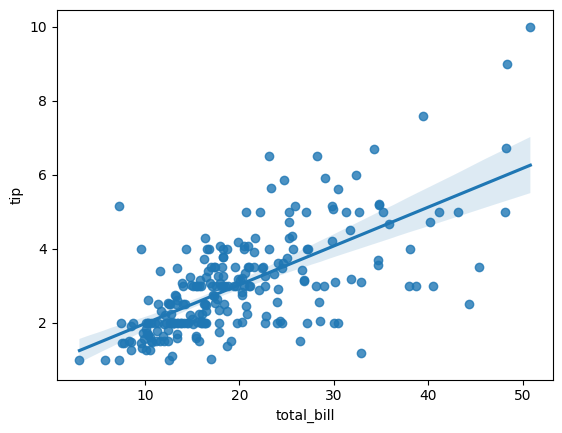

In [38]:
tips = sns.load_dataset("tips")
sns.regplot(x="total_bill", y="tip", data=tips, ci=95)

### Simulated data

### Voyager data

# Bonus
Daily averages of V1 LISM are very K41 monofractal! Certainly suggests not yet at outer scale...

In [21]:
data_res = data_full.resample("1d").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


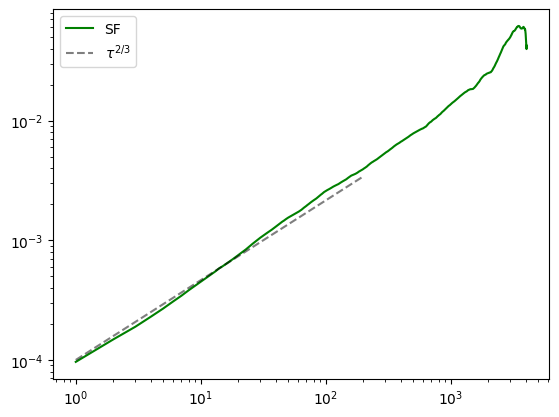

In [22]:
max_lag = 2000

sf_v1 = sf_funcs.compute_sf(
    data_res[["BR", "BT", "BN"]], np.arange(1, len(data_res)), [2], False, False, None
)

plt.plot(
    sf_v1.lag,
    sf_v1.sf_2,
    label="SF",
    color="green",
)

# Plot 2/3 power law
plt.plot(
    sf_true.lag,
    0.0001 * np.power(sf_true.lag, 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.5,
)
plt.legend()
plt.xscale("log")
plt.yscale("log")

Potentially relevant? [Statistical inference of random field auto-correlation structure from multiple sets of incomplete and sparse measurements using Bayesian compressive sampling-based bootstrapping](https://www.sciencedirect.com/science/article/pii/S0888327019300652#s0065)